# Find & Display the Outlier Radiograph

This notebook loads the final trained Conformer model, runs the full Miniaci
correction-angle pipeline on **every** image in the dataset, ranks all hemisphere
cases by absolute angular error, and displays the worst ("bad") image(s) with a
ground-truth / prediction landmark overlay.

It reuses the dataset, geometry, and overlay code from the training notebook so it
is drop-in compatible with the same environment (`CKD` repo, `/tf/data/hto`,
`best_model_global.pt`).

> **Note on the final model.** `best_model_global.pt` was trained on the 80% train
> split, so any image that was in its training set will usually be fit well and will
> *not* surface as the outlier. The 9.9° error from the cross-validation analysis
> occurred on a **held-out** image under the fold-3 checkpoint. The main scan below
> uses the final model as requested; the last (optional) section reconstructs the
> exact fold-3 validation split with `best_model_fold3.pt` to reproduce that specific
> case.

## Imports & configuration

In [1]:
import os
import json
import random
import math
import sys

import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader

%matplotlib inline

sys.path.append(os.path.abspath("CKD"))
from models import (
    Conformer_tiny_patch16_keypoint_half_heatmap,
    Conformer_small_patch16_keypoint_half_heatmap,
    Conformer_small_patch32_keypoint_half_heatmap,
    Conformer_base_patch16_keypoint_half_heatmap,
)
from utils import extract_coordinates

DATA_DIR       = "/tf/data/hto/xrays"
COCO_JSON_PATH = os.path.join(DATA_DIR, "hto_annotations.json")
if not os.path.exists(COCO_JSON_PATH):
    COCO_JSON_PATH = "hto_annotations.json"

SEED          = 42
TARGET_SIZE   = 768
HEATMAP_SCALE = 0.5
SIGMA         = 6.0
BATCH_SIZE    = 4

MODEL_VARIANT   = "small_p16"
CHECKPOINT_PATH = "best_model_global.pt"

# Any hemisphere whose absolute angle error is at or above this threshold is
# flagged as "bad" and displayed. If nothing exceeds it, the single worst case
# is shown anyway.
ERROR_THRESHOLD_DEG = 2.0
MAX_IMAGES_TO_SHOW  = 5

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Hardware device registered: {device}")

GLOBAL_KEYPOINT_NAMES = [
    "femur_head_lh", "knee_inner_lh", "ost_point_lh",
    "knee_outer_lh", "ankle_inner_lh", "ankle_outer_lh",
    "femur_head_rh", "knee_inner_rh", "ost_point_rh",
    "knee_outer_rh", "ankle_inner_rh", "ankle_outer_rh",
]

LANDMARK_COLORS = {
    "femur_head_lh":      "darkgreen",  "knee_inner_lh":    "darkblue",
    "ost_point_lh":       "darkred",    "knee_outer_lh":    "darkviolet",
    "ankle_inner_lh":     "darkorange", "ankle_outer_lh":   "teal",
    "fujisawa_lh":        "gold",       "ankle_c_lh":       "navy",
    "target_at_ankle_lh": "magenta",
    "femur_head_rh":      "lightgreen", "knee_inner_rh":    "lightblue",
    "ost_point_rh":       "lightcoral", "knee_outer_rh":    "plum",
    "ankle_inner_rh":     "sandybrown", "ankle_outer_rh":   "paleturquoise",
    "fujisawa_rh":        "khaki",      "ankle_c_rh":       "slategray",
    "target_at_ankle_rh": "violet",
}

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(SEED)

/usr/local/lib/python3.11/dist-packages/timm/models/helpers.py:7: FutureWarning: Importing from timm.models.helpers is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/usr/local/lib/python3.11/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.11/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/tf/notebooks/CKD/vision_transformer.py:370: UserWarning: Overwriting vit_small_patch16_224 in registry with vision_transformer.vit_small_patch16_224. This is because the name being registe

Hardware device registered: cuda


## Dataset & preprocessing

Identical to the training notebook (minus augmentation, which is only applied to
the `train` split). With `split="all"` the dataset returns every annotated image
in a fixed, deterministic order.

In [2]:
def preprocess_global_image(img, target_size=512):
    """Letterbox-resize *img* to a square canvas of *target_size* pixels."""
    orig_w, orig_h = img.size
    scale   = min(target_size / orig_w, target_size / orig_h)
    new_w   = int(orig_w * scale)
    new_h   = int(orig_h * scale)
    resized = img.resize((new_w, new_h), Image.Resampling.LANCZOS)
    pad_left = (target_size - new_w) // 2
    pad_top  = (target_size - new_h) // 2
    final_img = Image.new("RGB", (target_size, target_size), (0, 0, 0))
    final_img.paste(resized, (pad_left, pad_top))
    return final_img, scale, (pad_left, pad_top)


class GlobalRadiographKeypointDataset(Dataset):
    """COCO-style dataset for global 12-keypoint detection on long-leg radiographs.

    With split="all" (or any unrecognised split) every annotated sample is
    returned; augmentation is applied only when split == "train".
    """

    def __init__(
        self,
        coco_json_path,
        split="train",
        split_ratios=(0.8, 0.1, 0.1),
        target_size=512,
        heatmap_scale=0.25,
        sigma=2.0,
        seed=42,
        indices=None,
    ):
        super().__init__()
        self.target_size   = target_size
        self.heatmap_scale = heatmap_scale
        self.sigma         = sigma
        self.num_keypoints = 12
        self.split         = split

        with open(coco_json_path, "r") as f:
            coco_data = json.load(f)

        images_info = {img["id"]: img for img in coco_data.get("images", [])}
        anns_by_img = {}
        for ann in coco_data.get("annotations", []):
            img_id = ann.get("image_id")
            anns_by_img.setdefault(img_id, []).append(ann)

        valid_samples = []
        for img_id, anns in anns_by_img.items():
            if img_id not in images_info:
                continue
            img_info = images_info[img_id]
            img_w    = img_info.get("width", 2860)
            kps_flat = [-1.0, -1.0, 0] * 12
            has_kp   = False

            for ann in anns:
                kps = ann.get("keypoints", [])
                if not kps:
                    continue
                ann_cx = ann.get("bbox", [0, 0, 0, 0])[0] + ann.get("bbox", [0, 0, 0, 0])[2] / 2.0
                base   = 0 if ann_cx < img_w / 2.0 else 6
                cat_id = ann.get("category_id")
                if cat_id == 1 and len(kps) >= 2:
                    kps_flat[base * 3:(base + 1) * 3] = [kps[0], kps[1], 2 if kps[0] > 0 else 0]
                    if kps[0] > 0:
                        has_kp = True
                elif cat_id == 2 and len(kps) >= 9:
                    for k in range(3):
                        idx = base + 1 + k
                        kps_flat[idx * 3:(idx + 1) * 3] = [kps[k * 3], kps[k * 3 + 1], kps[k * 3 + 2]]
                        if kps[k * 3 + 2] > 0:
                            has_kp = True
                elif cat_id == 3 and len(kps) >= 6:
                    for k in range(2):
                        idx = base + 4 + k
                        kps_flat[idx * 3:(idx + 1) * 3] = [kps[k * 3], kps[k * 3 + 1], kps[k * 3 + 2]]
                        if kps[k * 3 + 2] > 0:
                            has_kp = True

            if has_kp:
                filename = img_info.get("file_name")
                img_dir  = os.path.dirname(coco_json_path) or "."
                if not os.path.exists(os.path.join(img_dir, filename)):
                    if os.path.exists(os.path.join("/tf/data/hto/xrays", os.path.basename(filename))):
                        img_dir = "/tf/data/hto/xrays"
                valid_samples.append({
                    "img_path":  os.path.join(img_dir, filename),
                    "orig_size": (img_w, img_info.get("height", 8000)),
                    "keypoints": kps_flat,
                })

        valid_samples.sort(key=lambda x: x["img_path"])
        random.seed(seed)
        random.shuffle(valid_samples)

        if indices is not None:
            self.samples = [valid_samples[i] for i in indices]
        else:
            n         = len(valid_samples)
            train_end = int(n * split_ratios[0])
            val_end   = train_end + int(n * split_ratios[1])
            self.samples = {
                "train": valid_samples[:train_end],
                "val":   valid_samples[train_end:val_end],
                "test":  valid_samples[val_end:],
            }.get(split, valid_samples)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        try:
            img = Image.open(sample["img_path"]).convert("RGB")
        except Exception:
            img = Image.new("RGB", sample["orig_size"], color=(128, 128, 128))

        processed_img, scale, padding = preprocess_global_image(img, self.target_size)

        final_kps = []
        for i in range(self.num_keypoints):
            kp_x = sample["keypoints"][i * 3]
            kp_y = sample["keypoints"][i * 3 + 1]
            kp_v = sample["keypoints"][i * 3 + 2]
            if kp_v > 0 and kp_x >= 0 and kp_y >= 0:
                final_kps.append([kp_x * scale + padding[0], kp_y * scale + padding[1]])
            else:
                final_kps.append([-1.0, -1.0])

        img_tensor = torch.from_numpy(np.array(processed_img)).permute(2, 0, 1).float() / 255.0
        img_tensor = (img_tensor - torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)) \
                     / torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

        return {
            "image":     img_tensor,
            "keypoint":  torch.tensor(final_kps, dtype=torch.float32),
            "img_path":  sample["img_path"],
            "orig_size": torch.tensor(sample["orig_size"]),
        }

In [3]:
if os.path.exists(COCO_JSON_PATH):
    full_ds = GlobalRadiographKeypointDataset(
        COCO_JSON_PATH, split="all",
        target_size=TARGET_SIZE, heatmap_scale=HEATMAP_SCALE, sigma=SIGMA, seed=SEED,
    )
    scan_loader = DataLoader(full_ds, batch_size=BATCH_SIZE, shuffle=False,
                             num_workers=2, pin_memory=True)
    print(f"Total images to scan: {len(full_ds)}")
else:
    print("Annotation file not found — data loading skipped.")

Total images to scan: 54


## Surgical geometry utilities

Identical to the training notebook: invert the letterbox transform, then apply the
Miniaci method (Fujisawa point, target-at-ankle intersection, correction angle α).

In [4]:
def map_global_to_orig(kp_final, orig_size, target_size=512):
    """Invert the letterbox transform back to original image coordinates."""
    orig_w, orig_h = orig_size
    scale    = min(target_size / orig_w, target_size / orig_h)
    pad_left = (target_size - int(orig_w * scale)) // 2
    pad_top  = (target_size - int(orig_h * scale)) // 2
    return np.array([(kp_final[0] - pad_left) / scale,
                     (kp_final[1] - pad_top)  / scale])


def calculate_intersection(p1, p2, target_y):
    """X-coordinate where line (p1 -> p2) crosses y = target_y."""
    if p2[0] == p1[0]:
        return p1[0]
    m = (p2[1] - p1[1]) / (p2[0] - p1[0])
    if m == 0:
        return p1[0] if abs(target_y - p1[1]) < 1e-9 else float("nan")
    return (target_y - p1[1]) / m + p1[0]


def evaluate_side_geometry(points):
    """Compute the Miniaci correction angle alpha for one leg hemisphere.

    Returns: alpha, fujisawa, ankle_c, target_at_ankle
    """
    ankle_c  = (points["ankle_inner"] + points["ankle_outer"]) / 2.0
    fujisawa = points["knee_inner"] + 0.625 * (points["knee_outer"] - points["knee_inner"])

    tx              = calculate_intersection(points["femur_head"], fujisawa, ankle_c[1])
    target_at_ankle = np.array([tx, ankle_c[1]])

    v_orig   = ankle_c         - points["ost_point"]
    v_target = target_at_ankle - points["ost_point"]
    raw      = abs(math.atan2(v_orig[1], v_orig[0]) - math.atan2(v_target[1], v_target[0]))
    alpha    = min(raw, 2 * math.pi - raw) * 180.0 / math.pi
    return alpha, fujisawa, ankle_c, target_at_ankle


_SIDE_KEYS = ["femur_head", "knee_inner", "ost_point",
              "knee_outer", "ankle_inner", "ankle_outer"]

## Load the final model

In [5]:
_model_map = {
    "tiny":      Conformer_tiny_patch16_keypoint_half_heatmap,
    "small_p16": Conformer_small_patch16_keypoint_half_heatmap,
    "small_p32": Conformer_small_patch32_keypoint_half_heatmap,
    "base":      Conformer_base_patch16_keypoint_half_heatmap,
}

model_global = _model_map[MODEL_VARIANT](num_keypoints=12).to(device)
if os.path.exists(CHECKPOINT_PATH):
    model_global.load_state_dict(torch.load(CHECKPOINT_PATH, weights_only=True))
    model_global.eval()
    print(f"Loaded final model from '{CHECKPOINT_PATH}'.")
else:
    print(f"Checkpoint '{CHECKPOINT_PATH}' not found — train and save it first.")

Loaded final model from 'best_model_global.pt'.


## Inference over every image

For each image and each leg hemisphere with complete ground-truth and predicted
landmarks, we run the full geometry pipeline and record the absolute correction-angle
error, keeping overlay-ready point dictionaries so the worst cases can be drawn later.

In [6]:
def run_full_inference(model, loader, dev):
    """Run the model over *loader* and return:
      results     : one dict per image, with overlay-ready res_l / res_r entries
      hemi_errors : a flat list of per-hemisphere error records
    """
    model.eval()
    results, hemi_errors = [], []

    with torch.no_grad():
        for batch in loader:
            imgs         = batch["image"].to(dev)
            pred_hms     = torch.sigmoid(model(imgs))
            coords_batch = extract_coordinates(pred_hms.cpu(), scale_factor=1.0 / HEATMAP_SCALE).numpy()
            gts_batch    = batch["keypoint"].numpy()
            paths_batch  = batch["img_path"]
            orig_sizes   = batch["orig_size"].numpy()

            for b in range(len(imgs)):
                orig_shape = orig_sizes[b]
                pred_c, gt_c, path_b = coords_batch[b], gts_batch[b], paths_batch[b]

                res_l = res_r = None
                for base, hemi_key in [(0, "res_l"), (6, "res_r")]:
                    pts_gt, pts_pred = {}, {}
                    for k_off, name in enumerate(_SIDE_KEYS):
                        slot = base + k_off
                        if gt_c[slot][0] >= 0:
                            pts_gt[name]   = map_global_to_orig(gt_c[slot],   orig_shape, TARGET_SIZE)
                            pts_pred[name] = map_global_to_orig(pred_c[slot], orig_shape, TARGET_SIZE)

                    if all(k in pts_gt for k in _SIDE_KEYS) and all(k in pts_pred for k in _SIDE_KEYS):
                        gt_alpha,   gt_fuji, gt_ank, gt_targ = evaluate_side_geometry(pts_gt)
                        pred_alpha, p_fuji,  p_ank,  p_targ  = evaluate_side_geometry(pts_pred)
                        pts_gt.update(fujisawa=gt_fuji,  ankle_c=gt_ank,  target_at_ankle=gt_targ)
                        pts_pred.update(fujisawa=p_fuji, ankle_c=p_ank,   target_at_ankle=p_targ)

                        side_label = "Left" if base == 0 else "Right"
                        result = {"side": side_label + " Image Hemisphere",
                                  "gt_angle": gt_alpha, "pred_angle": pred_alpha,
                                  "gt_pts": pts_gt,     "pred_pts": pts_pred}
                        if hemi_key == "res_l":
                            res_l = result
                        else:
                            res_r = result

                        hemi_errors.append({
                            "filename":   os.path.basename(path_b),
                            "img_path":   path_b,
                            "side":       side_label,
                            "gt_angle":   gt_alpha,
                            "pred_angle": pred_alpha,
                            "abs_err":    abs(pred_alpha - gt_alpha),
                        })

                if res_l or res_r:
                    results.append({"img_path": path_b,
                                    "filename": os.path.basename(path_b),
                                    "res_l": res_l, "res_r": res_r})
    return results, hemi_errors


if 'model_global' in locals() and 'scan_loader' in locals() and os.path.exists(CHECKPOINT_PATH):
    all_results, hemi_errors = run_full_inference(model_global, scan_loader, device)
    hemi_errors.sort(key=lambda d: d["abs_err"], reverse=True)

    errs = np.array([d["abs_err"] for d in hemi_errors])
    print(f"Scanned {len(all_results)} images, {len(hemi_errors)} hemisphere measurements.\n")
    print(f"Angle error  mean {errs.mean():.3f}\u00b0   median {np.median(errs):.3f}\u00b0   "
          f"max {errs.max():.3f}\u00b0   (>= {ERROR_THRESHOLD_DEG:.1f}\u00b0: {(errs >= ERROR_THRESHOLD_DEG).sum()} cases)\n")
    print("Worst 10 hemisphere cases:")
    print(f"{'rank':>4}  {'filename':<20}{'side':<7}{'GT (deg)':>10}{'pred (deg)':>12}{'abs err':>10}")
    print("-" * 65)
    for i, d in enumerate(hemi_errors[:10], 1):
        print(f"{i:>4}  {d['filename']:<20}{d['side']:<7}"
              f"{d['gt_angle']:>10.2f}{d['pred_angle']:>12.2f}{d['abs_err']:>10.3f}")
else:
    print("Model or data loader not available — scan skipped.")

Scanned 54 images, 105 hemisphere measurements.

Angle error  mean 0.331°   median 0.269°   max 1.407°   (>= 2.0°: 0 cases)

Worst 10 hemisphere cases:
rank  filename            side     GT (deg)  pred (deg)   abs err
-----------------------------------------------------------------
   1  29_0.png            Left         2.74        1.33     1.407
   2  52_0.png            Left        10.74        9.67     1.069
   3  32_0.png            Right        9.34        8.35     0.991
   4  4_0.png             Left         3.13        4.10     0.973
   5  23_0.png            Right       18.65       17.74     0.919
   6  6_0.png             Left         4.43        3.56     0.863
   7  15_0.png            Left         4.81        4.03     0.774
   8  30_0.png            Left         7.37        6.61     0.753
   9  62_0.png            Right       16.45       15.75     0.693
  10  32_0.png            Left        10.55       11.24     0.689


## Identify & display the bad image(s)

Every hemisphere at or above `ERROR_THRESHOLD_DEG` is shown with a side-by-side
ground-truth / prediction overlay (mechanical axes, tibial plateau, osteotomy hinge
lines, and the computed correction angle). If nothing crosses the threshold, the
single worst case is displayed so there is always something to inspect.

No hemisphere exceeded 2.0° — showing the single worst case.

BAD IMAGE: 29_0.png  |  Left hemisphere  |  GT 2.74°   pred 1.33°   abs err 1.407°


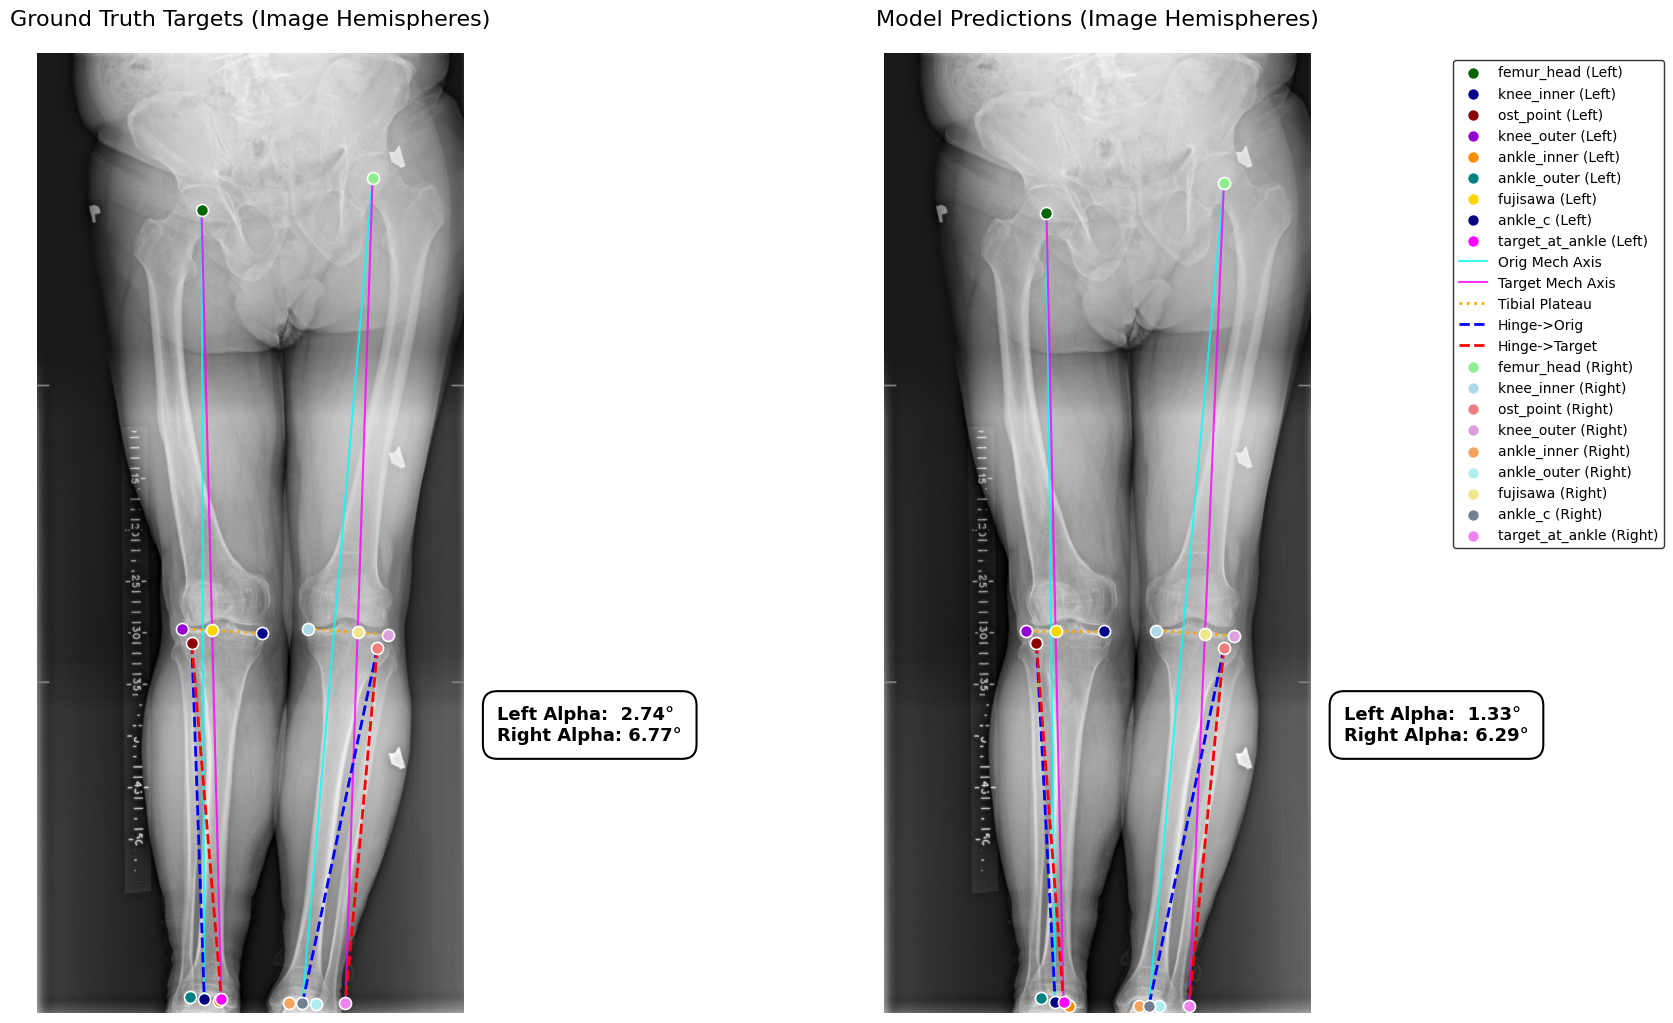

In [7]:
def draw_overlay(ax, img, data_item, is_gt=True):
    key   = "gt_angle" if is_gt else "pred_angle"
    title = ("Ground Truth Targets" if is_gt else "Model Predictions")
    ax.imshow(img, cmap="gray")
    ax.set_title(title + " (Image Hemispheres)", fontsize=16, pad=20)

    lines = []
    if data_item.get("res_l"):
        lines.append(f"Left Alpha:  {data_item['res_l'][key]:.2f}\u00b0")
    if data_item.get("res_r"):
        lines.append(f"Right Alpha: {data_item['res_r'][key]:.2f}\u00b0")
    if lines:
        ax.text(1.08, 0.3, "\n".join(lines), transform=ax.transAxes,
                ha="left", va="center", fontsize=13, weight="bold", color="black",
                bbox=dict(facecolor="white", edgecolor="black", boxstyle="round,pad=0.8", linewidth=1.5))

    for s_tag in ["res_l", "res_r"]:
        sd = data_item.get(s_tag)
        if not sd:
            continue
        pts    = sd["gt_pts"] if is_gt else sd["pred_pts"]
        suffix = "_lh" if s_tag == "res_l" else "_rh"
        side   = "Left" if s_tag == "res_l" else "Right"

        for k_name, coord in pts.items():
            if isinstance(coord, np.ndarray) and coord.shape == (2,):
                ax.scatter(coord[0], coord[1], s=75,
                           color=LANDMARK_COLORS.get(f"{k_name}{suffix}", "magenta"),
                           edgecolors="white", linewidths=1.2, zorder=5,
                           label=f"{k_name} ({side})")

        ax.plot([pts["femur_head"][0], pts["ankle_c"][0]],
                [pts["femur_head"][1], pts["ankle_c"][1]],
                color="cyan",    linestyle="-",  linewidth=1.5, alpha=0.8, zorder=2, label="Orig Mech Axis")
        ax.plot([pts["femur_head"][0], pts["target_at_ankle"][0]],
                [pts["femur_head"][1], pts["target_at_ankle"][1]],
                color="magenta", linestyle="-",  linewidth=1.5, alpha=0.8, zorder=3, label="Target Mech Axis")
        ax.plot([pts["knee_inner"][0], pts["knee_outer"][0]],
                [pts["knee_inner"][1], pts["knee_outer"][1]],
                color="orange",  linestyle=":",  linewidth=2,              zorder=4, label="Tibial Plateau")
        ax.plot([pts["ost_point"][0], pts["ankle_c"][0]],
                [pts["ost_point"][1], pts["ankle_c"][1]],
                color="blue",    linestyle="--", linewidth=2,              zorder=4, label="Hinge->Orig")
        ax.plot([pts["ost_point"][0], pts["target_at_ankle"][0]],
                [pts["ost_point"][1], pts["target_at_ankle"][1]],
                color="red",     linestyle="--", linewidth=2,              zorder=4, label="Hinge->Target")

    ax.axis("off")
    if not is_gt:
        handles, labels = ax.get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        if by_label:
            ax.legend(by_label.values(), by_label.keys(),
                      bbox_to_anchor=(1.32, 1.0), loc="upper left",
                      fontsize=10, frameon=True, facecolor="white", edgecolor="black")


def show_entry(entry):
    img = Image.open(entry["img_path"]).convert("RGB")
    fig, (ax_gt, ax_pred) = plt.subplots(1, 2, figsize=(22, 12))
    draw_overlay(ax_gt,   img, entry, is_gt=True)
    draw_overlay(ax_pred, img, entry, is_gt=False)
    plt.subplots_adjust(left=0.05, bottom=0.1, top=0.9, wspace=0.35, right=0.72)
    plt.show()


if 'hemi_errors' in locals() and hemi_errors:
    flagged = [d for d in hemi_errors if d["abs_err"] >= ERROR_THRESHOLD_DEG]
    if not flagged:
        print(f"No hemisphere exceeded {ERROR_THRESHOLD_DEG:.1f}\u00b0 — showing the single worst case.\n")
        flagged = hemi_errors[:1]
    else:
        print(f"{len(flagged)} hemisphere case(s) at or above {ERROR_THRESHOLD_DEG:.1f}\u00b0.\n")

    # Collapse to unique images (worst-first), capped at MAX_IMAGES_TO_SHOW.
    by_file, seen, to_show = {r["filename"]: r for r in all_results}, set(), []
    for d in flagged:
        if d["filename"] in seen:
            continue
        seen.add(d["filename"])
        to_show.append(d)
        if len(to_show) >= MAX_IMAGES_TO_SHOW:
            break

    for d in to_show:
        print("=" * 72)
        print(f"BAD IMAGE: {d['filename']}  |  {d['side']} hemisphere  |  "
              f"GT {d['gt_angle']:.2f}\u00b0   pred {d['pred_angle']:.2f}\u00b0   "
              f"abs err {d['abs_err']:.3f}\u00b0")
        print("=" * 72)
        show_entry(by_file[d["filename"]])
else:
    print("No inference results — nothing to display.")

## (Optional) Reproduce the cross-validation outlier

The 9.9° error from the analysis came from a **held-out** image in fold 3 of the
cross-validation, evaluated with that fold's checkpoint (`best_model_fold3.pt`). The
final model above may have trained on that image, so it can look fine in the main
scan. This cell reconstructs the exact fold-3 validation split (same
`KFold(shuffle=True, random_state=SEED)` over the same image order) and loads the
fold-3 checkpoint to surface that specific case. It runs only if the per-fold
checkpoint saved during cross-validation is present.

Loaded 'best_model_fold3.pt'; reconstructed fold 3 validation split (11 images).

Worst held-out case: 23_0.png (Right hemisphere)   GT 18.65°   pred 8.78°   abs err 9.878°


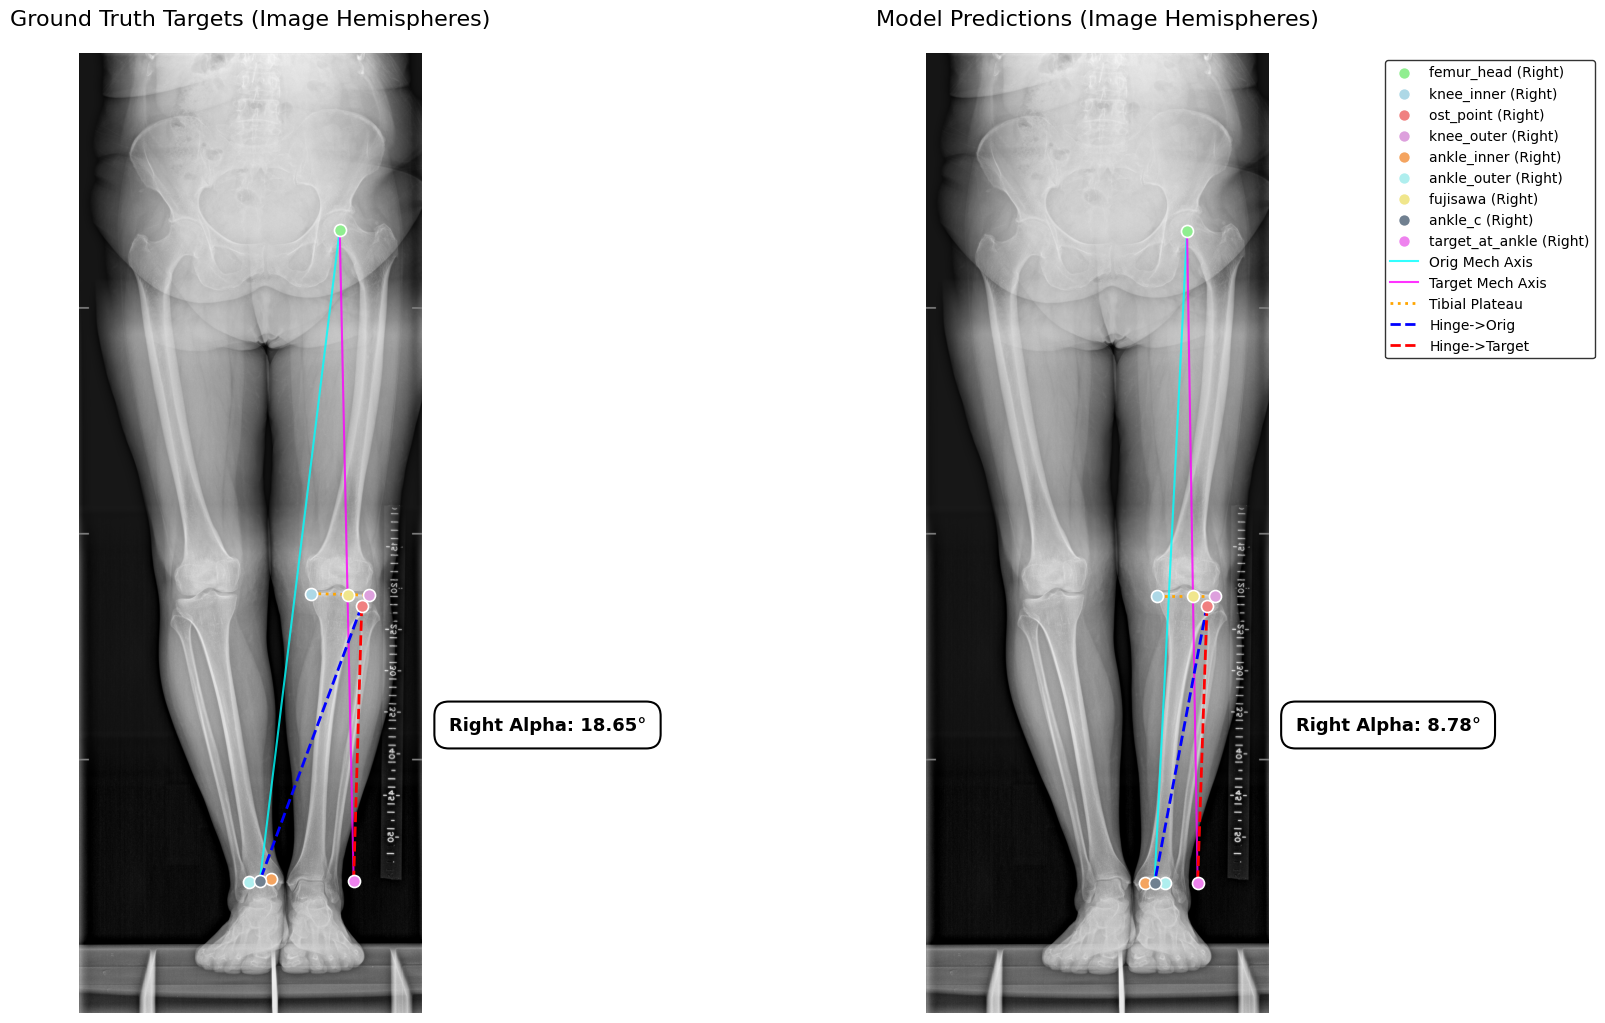

In [8]:
from sklearn.model_selection import KFold

FOLD_CHECKPOINT = "best_model_fold3.pt"   # saved as best_model_fold{N}.pt during CV
FOLD_INDEX      = 2                         # 0-based -> "FOLD 3/5"

if os.path.exists(COCO_JSON_PATH) and os.path.exists(FOLD_CHECKPOINT):
    n      = len(full_ds)
    kf     = KFold(n_splits=5, shuffle=True, random_state=SEED)
    splits = list(kf.split(np.arange(n)))
    _, val_idx = splits[FOLD_INDEX]

    val_ds = GlobalRadiographKeypointDataset(
        COCO_JSON_PATH, split="val", target_size=TARGET_SIZE,
        heatmap_scale=HEATMAP_SCALE, sigma=SIGMA, seed=SEED, indices=val_idx,
    )
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=2, pin_memory=True)

    fold_model = _model_map[MODEL_VARIANT](num_keypoints=12).to(device)
    fold_model.load_state_dict(torch.load(FOLD_CHECKPOINT, weights_only=True))
    fold_model.eval()
    print(f"Loaded '{FOLD_CHECKPOINT}'; reconstructed fold {FOLD_INDEX + 1} "
          f"validation split ({len(val_ds)} images).")

    fold_results, fold_errors = run_full_inference(fold_model, val_loader, device)
    fold_errors.sort(key=lambda d: d["abs_err"], reverse=True)

    worst = fold_errors[0]
    print(f"\nWorst held-out case: {worst['filename']} ({worst['side']} hemisphere)   "
          f"GT {worst['gt_angle']:.2f}\u00b0   pred {worst['pred_angle']:.2f}\u00b0   "
          f"abs err {worst['abs_err']:.3f}\u00b0")

    by_file_f = {r["filename"]: r for r in fold_results}
    show_entry(by_file_f[worst["filename"]])
else:
    missing = [p for p in (COCO_JSON_PATH, FOLD_CHECKPOINT) if not os.path.exists(p)]
    print("Skipped — missing file(s):", ", ".join(missing))

## Cultprit landmark
To pin the exact culprit landmark for the figure caption, print the per-landmark pixel deltas for this case:

In [9]:
e = by_file_f[worst["filename"]]["res_r"]   # right hemisphere on this image
for k in ["femur_head","knee_inner","knee_outer","ost_point",
          "ankle_inner","ankle_outer","fujisawa","ankle_c","target_at_ankle"]:
    d = float(np.linalg.norm(e["pred_pts"][k] - e["gt_pts"][k]))
    print(f"{k:16s} {d:7.1f} px")

femur_head           9.9 px
knee_inner          18.1 px
knee_outer          14.3 px
ost_point           12.5 px
ankle_inner        230.3 px
ankle_outer        571.4 px
fujisawa            13.8 px
ankle_c            400.1 px
target_at_ankle     31.4 px


And to back the tail explanation, check where 18.65° falls in the angle distribution:

In [10]:
gt_angles = np.array([d["gt_angle"] for d in hemi_errors])
print("50/90/max percentiles:", np.percentile(gt_angles, [50, 90, 100]).round(1), " this case: 18.65")

50/90/max percentiles: [ 6.3 13.  24.8]  this case: 18.65
